In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import random

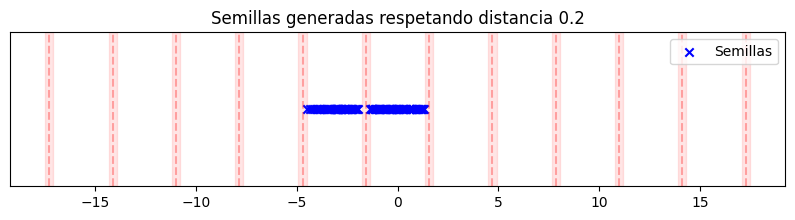

In [3]:
def generar_semillas_seguras(n_semillas, delta=0.1, rango_n=(-1, 1)):
    """
    n_semillas: Cantidad de semillas a generar
    delta: Distancia mínima a la asíntota (zona de seguridad)
    rango_n: Tupla (min, max) de los periodos (n*pi) donde buscar
    """
    
    # 1. Elegir aleatoriamente en qué periodo 'n' cae cada semilla
    # Si rango_n es (-5, 5), elegirá enteros entre -5 y 5
    n_elegidos = np.random.randint(rango_n[0], rango_n[1], n_semillas)
    
    # 2. Generar un desplazamiento aleatorio dentro de la zona segura
    # La zona segura va de (-pi/2 + delta) a (pi/2 - delta) respecto al centro n*pi
    limite_seguro = (np.pi / 2) - delta
    desplazamientos = np.random.uniform(-limite_seguro, limite_seguro, n_semillas)
    
    # 3. Calcular la posición final: Centro del periodo + desplazamiento
    semillas = (n_elegidos * np.pi) + desplazamientos
    
    return semillas




delta_seguridad = 0.2  # Distancia a la asíntota
semillas = generar_semillas_seguras(100, delta=delta_seguridad)

# Visualización para comprobar
plt.figure(figsize=(10, 2))
# Dibujar asíntotas en rojo
for n in range(-6, 6):
    asintota = np.pi/2 + n*np.pi
    plt.axvline(asintota, color='red', linestyle='--', alpha=0.3)
    # Dibujar la zona prohibida
    plt.axvspan(asintota - delta_seguridad, asintota + delta_seguridad, color='red', alpha=0.1)

plt.scatter(semillas, np.zeros_like(semillas), marker='x', color='blue', label='Semillas')
plt.title(f"Semillas generadas respetando distancia {delta_seguridad}")
plt.yticks([])
plt.legend()
plt.show()

Raíces pares: [np.float64(4.271095337633379)]
Raíces impares: [np.float64(2.8523418944568144), np.float64(5.679207796314466)]


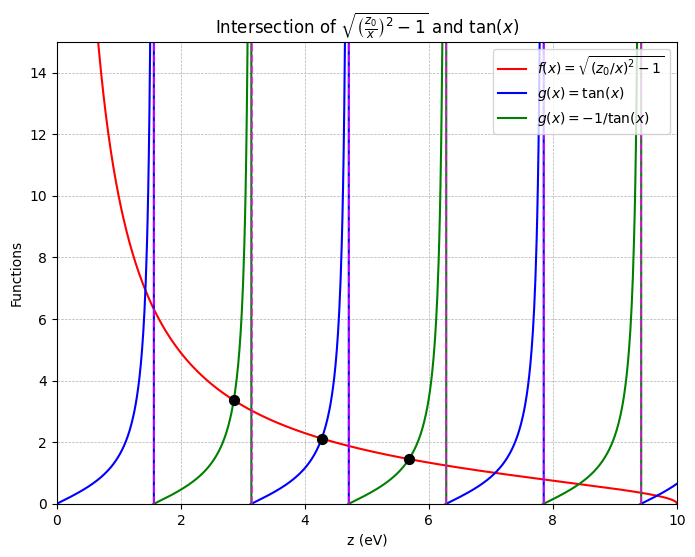

In [4]:
#Funciones NACHO---------------------

def sq(x, z0):
    """Función raíz cuadrada."""
    with np.errstate(all='ignore'):
        val = np.sqrt((z0 / x)**2 - 1) if x > 0 else np.nan
    return val

def tan_func(x):
    """Función tangente."""
    return np.tan(x)

def ctg_func(x):
    """Función cotangente (o -1/tan)."""
    return -1 / np.tan(x)

def diff_im(x, z0):
    """Diferencia para soluciones impares."""
    return sq(x, z0) - ctg_func(x)

def diff_par(x, z0):
    """Diferencia para soluciones pares."""
    return sq(x, z0) - tan_func(x)

# --- Método Newton-Raphson ---

def newton_im(sq, ctg_func, x0, eps, z0, max_iter=10000, step=0.005):
    xold = x0
    for i in range(max_iter):
        func = diff_im(xold, z0)
        dfunc = (diff_im(xold + step, z0) - diff_im(xold - step, z0)) / (2 * step)
        if dfunc == 0: break
        xnew = xold - func / dfunc
        if abs(xnew - xold) < eps:
            return xnew
        xold = xnew
    return None

def newton_par(sq, tan_func, x0, eps, z0, max_iter=10000, step=0.005):
    xold = x0
    for i in range(max_iter):
        func = diff_par(xold, z0)
        dfunc = (diff_par(xold + step, z0) - diff_par(xold - step, z0)) / (2 * step)
        if dfunc == 0: break
        xnew = xold - func / dfunc
        if abs(xnew - xold) < eps:
            return xnew
        xold = xnew
    return None

# --- Funciones para calcular puntos de intersección --- #MARCOS

def roots_par(z0, eps):
    par_def = []
    for i in range(2): # Buscando en los dos primeros intervalos
        a = i * np.pi
        b = i * np.pi + np.pi / 2
        vals_inside = np.linspace(a + 0.001, b - 0.001, 10000)
        rand = random.choice(vals_inside)
        root = newton_par(sq, tan_func, rand, eps, z0)
        if root is not None:
            if not any(abs(root - r) < 1e-5 for r in par_def):
                par_def.append(root)
    return par_def

def roots_im(z0, eps):
    im_def = []
    for i in range(2): # Buscando en los dos primeros intervalos
        a = i * np.pi + np.pi / 2
        b = i * np.pi + np.pi
        vals_inside = np.linspace(a + 0.000001, b - 0.000001, 100000)
        rand = random.choice(vals_inside)
        root = newton_im(sq, ctg_func, rand, eps, z0)
        if root is not None:
            if not any(abs(root - r) < 1e-5 for r in im_def):
                im_def.append(root)
    return im_def

# --- Función para graficar ---

def plot_functions(z0, x_par, x_im):
    x_values = np.linspace(0.001, 10, 1000)
    y_sq = [sq(x, z0) for x in x_values]
    y_ctg = [ctg_func(x) for x in x_values]
    y_tan = [tan_func(x) for x in x_values]

    plt.figure(figsize=(8, 6))
    plt.plot(x_values, y_sq, 'r', label=r'$f(x) = \sqrt{(z_0/x)^2 - 1}$')
    plt.plot(x_values, y_tan, 'b', label=r'$g(x) = \tan(x)$')
    plt.plot(x_values, y_ctg, 'g', label=r'$g(x) = -1/\tan(x)$')

    # Graficar singularidades (asíntotas)
    sing = np.arange(np.pi/2, 10, np.pi/2)
    for s in sing:
        plt.axvline(s, color="magenta", linestyle="--", alpha=0.7)

    # Graficar puntos de intersección pares
    for x in x_par:
        plt.scatter(x, sq(x, z0), color='black', s=50, zorder=5)
    
    # Graficar puntos de intersección impares
    for x in x_im:
        plt.scatter(x, sq(x, z0), color='black', s=50, zorder=5)

    plt.ylim(0, 15)
    plt.xlim(0, 10)
    plt.xlabel("z (eV)")
    plt.ylabel("Functions")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.title(r"Intersection of $\sqrt{\left(\frac{z_0}{x}\right)^2 - 1}$ and $\tan(x)$")
    plt.show()

# --- Ejecución principal ---
if __name__ == "__main__":
    z0 = 10
    eps = 1e-5
    x_par = roots_par(z0, eps)
    x_im = roots_im(z0, eps)
    
    print(f"Raíces pares: {x_par}")
    print(f"Raíces impares: {x_im}")
    
    plot_functions(z0, x_par, x_im)


Raíces pares: [np.float64(1.4275517800931634), np.float64(4.271095337633531), np.float64(7.068891237347651), np.float64(9.678884018488278)]
Raíces impares: [np.float64(2.852341894455552), np.float64(5.679207796333668), np.float64(8.423203932389944)]


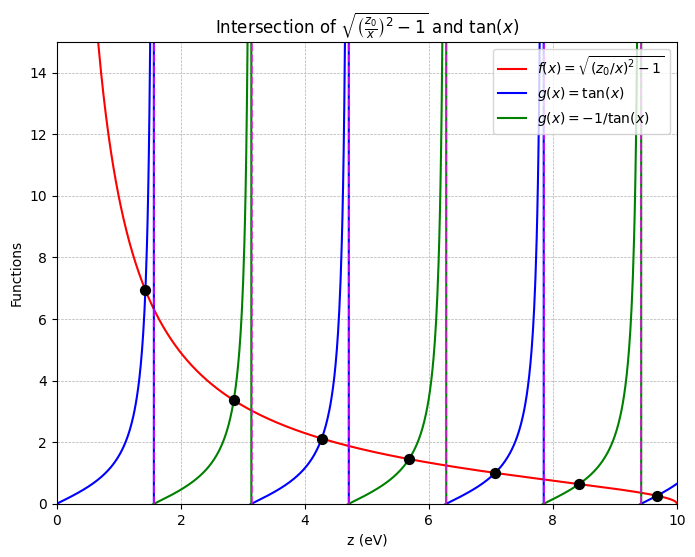

In [6]:
#Funciones NACHO---------------------

def sq(x, z0):
    """Función raíz cuadrada."""
    with np.errstate(all='ignore'):
        val = np.sqrt((z0 / x)**2 - 1) if x > 0 else np.nan
    return val

def tan_func(x):
    """Función tangente."""
    return np.tan(x)

def ctg_func(x):
    """Función cotangente (o -1/tan)."""
    return -1 / np.tan(x)

def diff_im(x, z0):
    """Diferencia para soluciones impares."""
    return sq(x, z0) - ctg_func(x)

def diff_par(x, z0):
    """Diferencia para soluciones pares."""
    return sq(x, z0) - tan_func(x)

# --- Método Newton-Raphson ---

def newton_im(sq, ctg_func, x0, eps, z0, max_iter=10000, step=0.005):
    xold = x0
    for _ in range(max_iter):
        func = diff_im(xold, z0)
        dfunc = (diff_im(xold + step, z0) - diff_im(xold - step, z0)) / (2 * step)
        if dfunc == 0: break
        xnew = xold - func / dfunc
        if abs(xnew - xold) < eps:
            return xnew
        xold = xnew
    return None

def newton_par(sq, tan_func, x0, eps, z0, max_iter=10000, step=0.005):
    xold = x0
    for _ in range(max_iter):
        func = diff_par(xold, z0)
        dfunc = (diff_par(xold + step, z0) - diff_par(xold - step, z0)) / (2 * step)
        if dfunc == 0: break
        xnew = xold - func / dfunc
        if abs(xnew - xold) < eps:
            return xnew
        xold = xnew
    return None

# --- Funciones para calcular puntos de intersección --- #MARCOS

def roots_par(z0, eps):
    par_def = []
    # El valor máximo de x es z0, no tiene sentido buscar más allá
    # Buscamos en intervalos de [n*pi, n*pi + pi/2]
    num_intervalos = int(z0 / np.pi) + 1
    
    for i in range(num_intervalos):
        a = i * np.pi
        b = min(i * np.pi + np.pi / 2, z0 - 1e-9) # No pasarse de z0 ni de la asíntota
        
        if a > z0: break
        
        # Muestreo sistemático: probamos en el centro del intervalo
        # o en varios puntos si el intervalo es grande
        seeds = np.linspace(a + 0.01, b - 0.01, 5)
        for x0 in seeds:
            root = newton_par(sq, tan_func, x0, eps, z0)
            if root is not None and 0 < root < z0:
                if not any(abs(root - r) < 1e-4 for r in par_def):
                    par_def.append(root)
    return sorted(par_def)

def roots_im(z0, eps):
    im_def = []
    num_intervalos = int(z0 / np.pi) + 1
    
    for i in range(num_intervalos):
        a = i * np.pi + np.pi / 2
        b = min(i * np.pi + np.pi, z0 - 1e-9)
        
        if a > z0: break
        
        seeds = np.linspace(a + 0.01, b - 0.01, 5)
        for x0 in seeds:
            root = newton_im(sq, ctg_func, x0, eps, z0)
            if root is not None and 0 < root < z0:
                if not any(abs(root - r) < 1e-4 for r in im_def):
                    im_def.append(root)
    return sorted(im_def)

# --- Función para graficar ---

def plot_functions(z0, x_par, x_im):
    x_values = np.linspace(0.001, 10, 1000)
    y_sq = [sq(x, z0) for x in x_values]
    y_ctg = [ctg_func(x) for x in x_values]
    y_tan = [tan_func(x) for x in x_values]

    plt.figure(figsize=(8, 6))
    plt.plot(x_values, y_sq, 'r', label=r'$f(x) = \sqrt{(z_0/x)^2 - 1}$')
    plt.plot(x_values, y_tan, 'b', label=r'$g(x) = \tan(x)$')
    plt.plot(x_values, y_ctg, 'g', label=r'$g(x) = -1/\tan(x)$')

    # Graficar singularidades (asíntotas)
    sing = np.arange(np.pi/2, 10, np.pi/2)
    for s in sing:
        plt.axvline(s, color="magenta", linestyle="--", alpha=0.7)

    # Graficar puntos de intersección pares
    for x in x_par:
        
        plt.scatter(x, sq(x, z0), color='black', s=50, zorder=5)
    
    # Graficar puntos de intersección impares
    for x in x_im:

        plt.scatter(x, sq(x, z0), color='black', s=50, zorder=5)

    plt.ylim(0, 15)
    plt.xlim(0, 10)
    plt.xlabel("z (eV)")
    plt.ylabel("Functions")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.title(r"Intersection of $\sqrt{\left(\frac{z_0}{x}\right)^2 - 1}$ and $\tan(x)$")
    plt.show()


# --- Ejecución principal ---

if __name__ == "__main__":
    a= 3
    V = 3
    m_ele=  9.10938356 * 10**(-31) 
    Hbar= 1.0545718 * 10**(-34) # J·s
    
    z0 = 10

    eps = 1e-5
    x_par = roots_par(z0, eps)
    x_im = roots_im(z0, eps)

    print(f"Raíces pares: {x_par}")
    print(f"Raíces impares: {x_im}")

    plot_functions(z0, x_par, x_im)